## 1. Imports

In [1]:
import h5py
import numpy as np
import os
import copy
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from scipy.stats import zscore
from scipy.signal import decimate

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
folder_path_intra = r"/Users/chetlurvasundhara/Documents/deep learning /Final Project data/Intra"
folder_path_cross = r"/Users/chetlurvasundhara/Documents/deep learning /Final Project data/Cross"

DOWNSAMPLE_FACTOR = 20          # 2034 Hz → ~102 Hz
WINDOW_SIZE       = 200         # timepoints (~2 s at 102 Hz)
STEP_SIZE         = 200         # no overlap — epochs are independent
N_CHANNELS        = 248
CLASS_NAMES       = ['Rest', 'Motor', 'Memory', 'Story/Math']

def get_label(filename):
    if 'rest'           in filename: return 0
    elif 'motor'        in filename: return 1
    elif 'working_memory' in filename: return 2
    elif 'story'        in filename: return 3
    return -1

def sliding_window(data, window, step):
    """
    Slice a (n_channels, T) array into windows.
    Returns (n_epochs, n_channels, window).
    """
    epochs = []
    for start in range(0, data.shape[1] - window + 1, step):
        epochs.append(data[:, start:start + window])
    return np.array(epochs, dtype=np.float32)

def load_folder(folder_path):
    X, y = [], []
    for file in sorted(os.listdir(folder_path)):
        if not file.endswith('.h5'):
            continue
        with h5py.File(os.path.join(folder_path, file), 'r') as f:
            key  = list(f.keys())[0]
            data = f[key][:]
        data   = decimate(data, DOWNSAMPLE_FACTOR, axis=1)   # (248, ~1781)
        data   = zscore(data, axis=1)                         # normalise per channel
        data   = np.nan_to_num(data, nan=0.0)
        epochs = sliding_window(data, WINDOW_SIZE, STEP_SIZE) # (8, 248, 200)
        label  = get_label(file)
        X.append(epochs)
        y.extend([label] * len(epochs))
    return np.concatenate(X, axis=0), np.array(y, dtype=np.int64)

# ── Load all splits ────────────────────────────────────────────────────────────
X_intra_train, y_intra_train = load_folder(folder_path_intra + '/train')
X_intra_test,  y_intra_test  = load_folder(folder_path_intra + '/test')
X_cross_train, y_cross_train = load_folder(folder_path_cross + '/train')
X_cross_test1, y_cross_test1 = load_folder(folder_path_cross + '/test1')
X_cross_test2, y_cross_test2 = load_folder(folder_path_cross + '/test2')
X_cross_test3, y_cross_test3 = load_folder(folder_path_cross + '/test3')

X_cross_test = np.concatenate([X_cross_test1, X_cross_test2, X_cross_test3], axis=0)
y_cross_test = np.concatenate([y_cross_test1, y_cross_test2, y_cross_test3], axis=0)

print('INTRA train:', X_intra_train.shape, y_intra_train.shape)
print('INTRA test: ', X_intra_test.shape,  y_intra_test.shape)
print('CROSS train:', X_cross_train.shape, y_cross_train.shape)
print('CROSS test: ', X_cross_test.shape,  y_cross_test.shape)
# Expected: (256, 248, 200), (64, 248, 200), (512, 248, 200), (384, 248, 200)

INTRA train: (256, 248, 200) (256,)
INTRA test:  (64, 248, 200) (64,)
CROSS train: (512, 248, 200) (512,)
CROSS test:  (384, 248, 200) (384,)


In [3]:
def augment(x: torch.Tensor, noise_std: float = 0.05, crop_ratio: float = 0.1) -> torch.Tensor:
    """
    x : (B, channels, time)
    Returns an augmented copy of the same shape.
    """
    x = x + noise_std * torch.randn_like(x)
    T = x.shape[-1]
    max_crop = int(T * crop_ratio)
    if max_crop > 0:
        start     = torch.randint(0, max_crop, (1,)).item()
        x_cropped = x[:, :, start:]
        x         = F.pad(x_cropped, (0, T - x_cropped.shape[-1]))
    return x

In [4]:
class EEGNet(nn.Module):
    def __init__(self, n_channels=248, n_times=200,
                 F1=8, D=2, kernel_size=32, dropout=0.5, embed_dim=128):
        super().__init__()
        F2 = F1 * D

        # Block 1 — temporal + depthwise spatial
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, kernel_size), padding=(0, kernel_size // 2), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F2, (n_channels, 1), groups=F1, bias=False),  # depthwise spatial
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(dropout),
        )

        # Block 2 — separable conv
        self.block2 = nn.Sequential(
            nn.Conv2d(F2, F2, (1, 16), padding=(0, 8), groups=F2, bias=False),
            nn.Conv2d(F2, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout(dropout),
        )

        # Infer flatten size dynamically
        with torch.no_grad():
            dummy    = torch.zeros(1, 1, n_channels, n_times)
            flat_dim = self.block2(self.block1(dummy)).view(1, -1).shape[1]

        self.fc = nn.Sequential(nn.Flatten(), nn.Linear(flat_dim, embed_dim))

    def forward(self, x):
        # x: (B, C, T) → unsqueeze to (B, 1, C, T) for Conv2d
        x = x.unsqueeze(1)
        x = self.block1(x)
        x = self.block2(x)
        return self.fc(x)   # (B, embed_dim)


class ProjectionHead(nn.Module):
    """MLP projection head — used only during contrastive pretraining."""
    def __init__(self, embed_dim=128, proj_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_dim, embed_dim), nn.ReLU(),
            nn.Linear(embed_dim, proj_dim),
        )
    def forward(self, x):
        return self.net(x)


class ContrastiveModel(nn.Module):
    def __init__(self, encoder, projector):
        super().__init__()
        self.encoder   = encoder
        self.projector = projector
    def forward(self, x):
        return F.normalize(self.projector(self.encoder(x)), dim=1)


# ── Sanity check ───────────────────────────────────────────────────────────────
enc   = EEGNet(n_channels=N_CHANNELS, n_times=WINDOW_SIZE).to(device)
dummy = torch.randn(4, N_CHANNELS, WINDOW_SIZE).to(device)
print('Encoder output shape:', enc(dummy).shape)  # expect (4, 128)

Encoder output shape: torch.Size([4, 128])


In [5]:
class SupConLoss(nn.Module):
    """
    Supervised Contrastive Loss (Khosla et al., NeurIPS 2020).
    features : (B, dim) - L2-normalised projections
    labels   : (B,)     - integer class labels

    Fix vs previous version:
      The old code set the diagonal of `sim` to -inf and then computed
      `log_prob * pos_mask`. On the diagonal that is (-inf) * 0 = NaN, which
      propagated through the whole batch and made the SupCon loss NaN every
      epoch (so pretraining never actually trained the encoder).
      Here we never use -inf: we zero out the diagonal inside the denominator
      sum, and subtract the per-row max for numerical stability.
    """
    def __init__(self, temperature: float = 0.07):
        super().__init__()
        self.temperature = temperature

    def forward(self, features: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
        B   = features.shape[0]
        dev = features.device

        # cosine similarities (features are already L2-normalised), scaled by temperature
        sim = torch.matmul(features, features.T) / self.temperature      # (B, B)

        # numerical stability: subtract per-row max (detached -> no grad effect)
        sim = sim - sim.max(dim=1, keepdim=True)[0].detach()

        self_mask = torch.eye(B, dtype=torch.bool, device=dev)

        # positives: same label, excluding the sample itself
        labels   = labels.view(-1, 1)
        pos_mask = (labels == labels.T) & ~self_mask

        # denominator runs over all NON-self pairs.
        # Zero out the diagonal in exp-space instead of using -inf -> avoids NaN.
        exp_sim  = torch.exp(sim).masked_fill(self_mask, 0.0)
        log_prob = sim - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-12)

        # average log-prob over the positives of each anchor
        n_pos       = pos_mask.sum(dim=1)
        mean_lp_pos = (log_prob * pos_mask).sum(dim=1) / n_pos.clamp(min=1)

        # only anchors that actually have at least one positive contribute
        return -mean_lp_pos[n_pos > 0].mean()

## 6. Training Utilities

In [6]:
def make_loader(X, y, batch_size, shuffle=True):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def pretrain_contrastive(model, loader, optimizer, criterion,
                         epochs=60, noise_std=0.05, crop_ratio=0.1):
    """
    Phase 1 — Contrastive pretraining.
    Two augmented views are generated per batch and concatenated;
    this doubles effective batch size and the number of positive pairs.
    """
    model.train()
    history = []
    for epoch in range(epochs):
        total = 0.0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            views  = torch.cat([augment(xb, noise_std, crop_ratio),
                                 augment(xb, noise_std, crop_ratio)], dim=0)
            labels = torch.cat([yb, yb], dim=0)
            loss   = criterion(model(views), labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total += loss.item()
        avg = total / len(loader)
        history.append(avg)
        if (epoch + 1) % 10 == 0:
            print(f'  [Pretrain] Epoch {epoch+1:3d}/{epochs} | SupCon Loss: {avg:.4f}')
    return history


def train_classifier(encoder, clf, loader, optimizer, criterion, epochs=50):
    """
    Phase 2 — Linear evaluation on frozen encoder.
    Freezing prevents catastrophic forgetting of the contrastive representation.
    """
    encoder.eval(); clf.train()
    hist_loss, hist_acc = [], []
    for epoch in range(epochs):
        total_loss, correct, n = 0.0, 0, 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            with torch.no_grad():
                emb = encoder(xb)
            logits = clf(emb)
            loss   = criterion(logits, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
            correct    += (logits.argmax(1) == yb).sum().item()
            n          += yb.size(0)
        hist_loss.append(total_loss / len(loader))
        hist_acc.append(correct / n)
        if (epoch + 1) % 10 == 0:
            print(f'  [Classify] Epoch {epoch+1:3d}/{epochs} | Loss: {hist_loss[-1]:.4f} | Acc: {hist_acc[-1]:.4f}')
    return hist_loss, hist_acc


@torch.no_grad()
def evaluate(encoder, clf, loader):
    encoder.eval(); clf.eval()
    preds, labels = [], []
    for xb, yb in loader:
        preds.append(clf(encoder(xb.to(device))).argmax(1).cpu())
        labels.append(yb)
    preds  = torch.cat(preds).numpy()
    labels = torch.cat(labels).numpy()
    return (preds == labels).mean(), preds, labels


def plot_history(values, ylabel, title):
    plt.figure(figsize=(7, 3))
    plt.plot(values)
    plt.xlabel('Epoch'); plt.ylabel(ylabel); plt.title(title)
    plt.tight_layout(); plt.show()


def plot_confusion(labels, preds, title):
    cm   = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(title); plt.tight_layout(); plt.show()

=== Phase 1: Contrastive Pretraining (Intra) ===
  [Pretrain] Epoch  10/60 | SupCon Loss: 4.8375
  [Pretrain] Epoch  20/60 | SupCon Loss: 4.5442
  [Pretrain] Epoch  30/60 | SupCon Loss: 4.3733
  [Pretrain] Epoch  40/60 | SupCon Loss: 4.3101
  [Pretrain] Epoch  50/60 | SupCon Loss: 4.2965
  [Pretrain] Epoch  60/60 | SupCon Loss: 4.2904


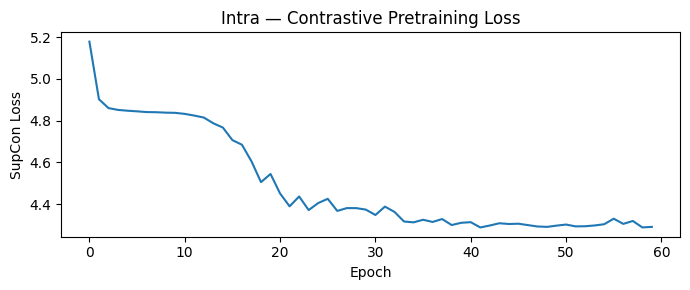

In [7]:
# ── Hyper-parameters ──────────────────────────────────────────────────────────
# Batch size 64: with 256 training samples we can fit 4 batches;
# larger batches → more positive pairs per SupCon step.
BATCH_SIZE      = 64
PRETRAIN_LR     = 1e-3
CLF_LR          = 1e-3
PRETRAIN_EPOCHS = 60
CLF_EPOCHS      = 50
TEMPERATURE     = 0.07
EMBED_DIM       = 128
PROJ_DIM        = 64

intra_encoder   = EEGNet(n_channels=N_CHANNELS, n_times=WINDOW_SIZE, embed_dim=EMBED_DIM).to(device)
intra_projector = ProjectionHead(EMBED_DIM, PROJ_DIM).to(device)
intra_con_model = ContrastiveModel(intra_encoder, intra_projector).to(device)

supcon_loss  = SupConLoss(temperature=TEMPERATURE)
pretrain_opt = torch.optim.Adam(intra_con_model.parameters(), lr=PRETRAIN_LR, weight_decay=1e-4)

intra_train_loader = make_loader(X_intra_train, y_intra_train, BATCH_SIZE)

print('=== Phase 1: Contrastive Pretraining (Intra) ===')
intra_pretrain_hist = pretrain_contrastive(
    intra_con_model, intra_train_loader, pretrain_opt, supcon_loss,
    epochs=PRETRAIN_EPOCHS
)
plot_history(intra_pretrain_hist, 'SupCon Loss', 'Intra — Contrastive Pretraining Loss')

=== Phase 2: Classifier Training (Intra) ===
  [Classify] Epoch  10/50 | Loss: 0.9393 | Acc: 0.5586
  [Classify] Epoch  20/50 | Loss: 0.8748 | Acc: 0.5820
  [Classify] Epoch  30/50 | Loss: 0.8483 | Acc: 0.6133
  [Classify] Epoch  40/50 | Loss: 0.8321 | Acc: 0.6172
  [Classify] Epoch  50/50 | Loss: 0.8202 | Acc: 0.6406


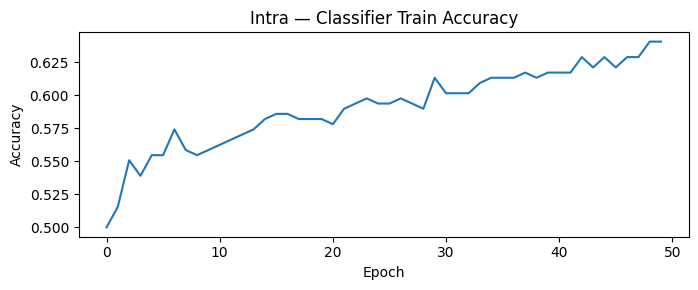

In [8]:
intra_clf = nn.Linear(EMBED_DIM, 4).to(device)
clf_opt   = torch.optim.Adam(intra_clf.parameters(), lr=CLF_LR, weight_decay=1e-4)
ce_loss   = nn.CrossEntropyLoss()

print('=== Phase 2: Classifier Training (Intra) ===')
intra_clf_loss, intra_clf_acc = train_classifier(
    intra_encoder, intra_clf, intra_train_loader, clf_opt, ce_loss,
    epochs=CLF_EPOCHS
)
plot_history(intra_clf_acc, 'Accuracy', 'Intra — Classifier Train Accuracy')


=== Intra-Subject Results ===
Train accuracy : 0.6406
Test  accuracy : 0.4844

              precision    recall  f1-score   support

        Rest       0.83      0.94      0.88        16
       Motor       0.46      0.38      0.41        16
      Memory       0.29      0.25      0.27        16
  Story/Math       0.32      0.38      0.34        16

    accuracy                           0.48        64
   macro avg       0.47      0.48      0.48        64
weighted avg       0.47      0.48      0.48        64



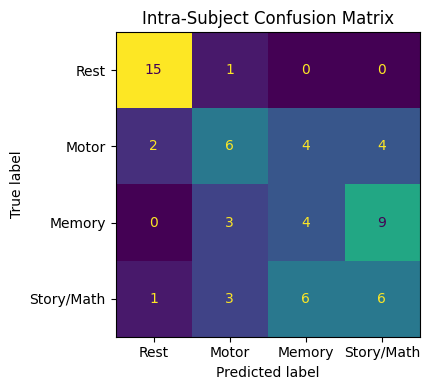

In [9]:
intra_test_loader = make_loader(X_intra_test, y_intra_test, BATCH_SIZE, shuffle=False)

intra_train_acc, _, _              = evaluate(intra_encoder, intra_clf, intra_train_loader)
intra_test_acc,  intra_preds, intra_labels = evaluate(intra_encoder, intra_clf, intra_test_loader)

print(f'\n=== Intra-Subject Results ===')
print(f'Train accuracy : {intra_train_acc:.4f}')
print(f'Test  accuracy : {intra_test_acc:.4f}')
print()
print(classification_report(intra_labels, intra_preds, target_names=CLASS_NAMES))
plot_confusion(intra_labels, intra_preds, 'Intra-Subject Confusion Matrix')

=== Phase 1: Contrastive Pretraining (Cross) ===
  [Pretrain] Epoch  10/60 | SupCon Loss: 5.5523
  [Pretrain] Epoch  20/60 | SupCon Loss: 5.5458
  [Pretrain] Epoch  30/60 | SupCon Loss: 5.5419
  [Pretrain] Epoch  40/60 | SupCon Loss: 5.5382
  [Pretrain] Epoch  50/60 | SupCon Loss: 5.5254
  [Pretrain] Epoch  60/60 | SupCon Loss: 5.4445


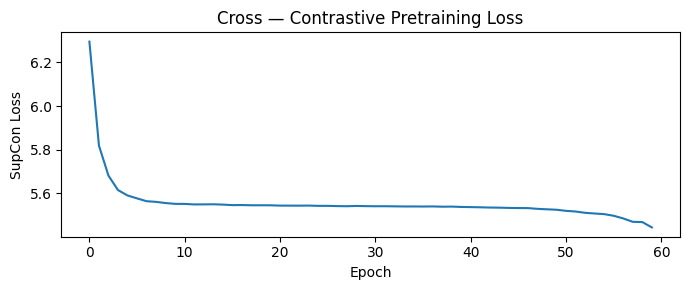

In [10]:
# Larger batch for cross: 512 samples → batch 128 gives 4 batches per epoch
CROSS_BATCH      = 128
CROSS_PRE_LR     = 5e-4
CROSS_CLF_LR     = 5e-4
CROSS_PRE_EPOCHS = 60
CROSS_CLF_EPOCHS = 50

cross_encoder   = EEGNet(n_channels=N_CHANNELS, n_times=WINDOW_SIZE, embed_dim=EMBED_DIM).to(device)
cross_projector = ProjectionHead(EMBED_DIM, PROJ_DIM).to(device)
cross_con_model = ContrastiveModel(cross_encoder, cross_projector).to(device)

cross_pre_opt      = torch.optim.Adam(cross_con_model.parameters(), lr=CROSS_PRE_LR, weight_decay=1e-4)
cross_train_loader = make_loader(X_cross_train, y_cross_train, CROSS_BATCH)

print('=== Phase 1: Contrastive Pretraining (Cross) ===')
cross_pretrain_hist = pretrain_contrastive(
    cross_con_model, cross_train_loader, cross_pre_opt, supcon_loss,
    epochs=CROSS_PRE_EPOCHS
)
plot_history(cross_pretrain_hist, 'SupCon Loss', 'Cross — Contrastive Pretraining Loss')

=== Phase 2: Classifier Training (Cross) ===
  [Classify] Epoch  10/50 | Loss: 1.3651 | Acc: 0.2812
  [Classify] Epoch  20/50 | Loss: 1.3279 | Acc: 0.3340
  [Classify] Epoch  30/50 | Loss: 1.2989 | Acc: 0.4219
  [Classify] Epoch  40/50 | Loss: 1.2739 | Acc: 0.4766
  [Classify] Epoch  50/50 | Loss: 1.2518 | Acc: 0.5098


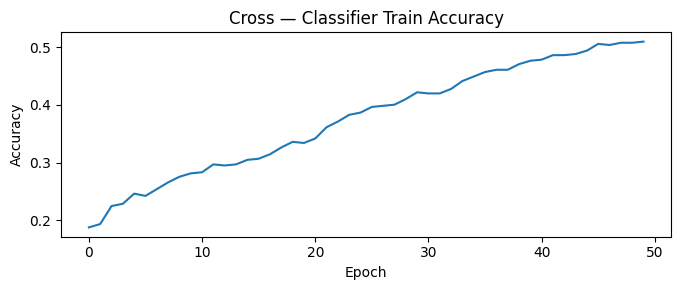

In [11]:
cross_clf     = nn.Linear(EMBED_DIM, 4).to(device)
cross_clf_opt = torch.optim.Adam(cross_clf.parameters(), lr=CROSS_CLF_LR, weight_decay=1e-4)

print('=== Phase 2: Classifier Training (Cross) ===')
cross_clf_loss, cross_clf_acc = train_classifier(
    cross_encoder, cross_clf, cross_train_loader, cross_clf_opt, ce_loss,
    epochs=CROSS_CLF_EPOCHS
)
plot_history(cross_clf_acc, 'Accuracy', 'Cross — Classifier Train Accuracy')


=== Cross-Subject Results ===
Train accuracy : 0.5117
Test  accuracy : 0.2474

              precision    recall  f1-score   support

        Rest       0.38      0.30      0.34        96
       Motor       0.22      0.32      0.26        96
      Memory       0.24      0.20      0.22        96
  Story/Math       0.18      0.17      0.17        96

    accuracy                           0.25       384
   macro avg       0.26      0.25      0.25       384
weighted avg       0.26      0.25      0.25       384



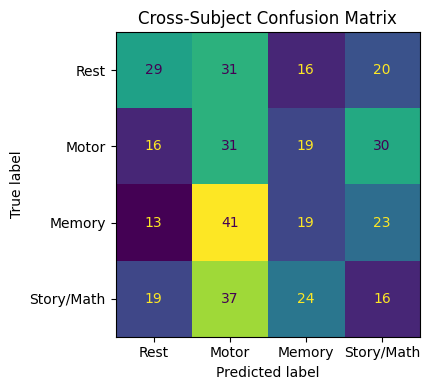

In [12]:
cross_test_loader = make_loader(X_cross_test, y_cross_test, CROSS_BATCH, shuffle=False)

cross_train_acc, _, _                = evaluate(cross_encoder, cross_clf, cross_train_loader)
cross_test_acc,  cross_preds, cross_labels = evaluate(cross_encoder, cross_clf, cross_test_loader)

print(f'\n=== Cross-Subject Results ===')
print(f'Train accuracy : {cross_train_acc:.4f}')
print(f'Test  accuracy : {cross_test_acc:.4f}')
print()
print(classification_report(cross_labels, cross_preds, target_names=CLASS_NAMES))
plot_confusion(cross_labels, cross_preds, 'Cross-Subject Confusion Matrix')

Setting                    Train Acc   Test Acc
-----------------------------------------------
Intra-subject                 0.6406     0.4844
Cross-subject                 0.5117     0.2474


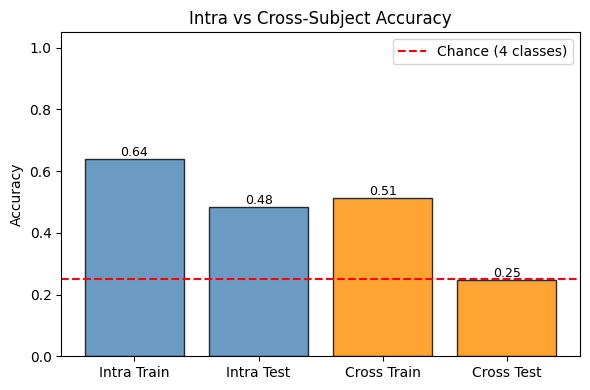

In [13]:
print('=' * 47)
print(f"{'Setting':<25} {'Train Acc':>10} {'Test Acc':>10}")
print('-' * 47)
print(f"{'Intra-subject':<25} {intra_train_acc:>10.4f} {intra_test_acc:>10.4f}")
print(f"{'Cross-subject':<25} {cross_train_acc:>10.4f} {cross_test_acc:>10.4f}")
print('=' * 47)

fig, ax = plt.subplots(figsize=(6, 4))
labels_ = ['Intra Train', 'Intra Test', 'Cross Train', 'Cross Test']
values_ = [intra_train_acc, intra_test_acc, cross_train_acc, cross_test_acc]
colors_ = ['steelblue', 'steelblue', 'darkorange', 'darkorange']
bars    = ax.bar(labels_, values_, color=colors_, alpha=0.8, edgecolor='black')
ax.axhline(0.25, color='red', linestyle='--', label='Chance (4 classes)')
ax.set_ylim(0, 1.05); ax.set_ylabel('Accuracy')
ax.set_title('Intra vs Cross-Subject Accuracy')
ax.legend()
for b, v in zip(bars, values_):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()


--- τ = 0.05 ---
  [Pretrain] Epoch  10/60 | SupCon Loss: 4.8464
  [Pretrain] Epoch  20/60 | SupCon Loss: 4.8375
  [Pretrain] Epoch  30/60 | SupCon Loss: 4.7535
  [Pretrain] Epoch  40/60 | SupCon Loss: 4.3804
  [Pretrain] Epoch  50/60 | SupCon Loss: 4.3087
  [Pretrain] Epoch  60/60 | SupCon Loss: 4.3180
  [Classify] Epoch  10/50 | Loss: 1.0673 | Acc: 0.5039
  [Classify] Epoch  20/50 | Loss: 0.9568 | Acc: 0.5195
  [Classify] Epoch  30/50 | Loss: 0.9072 | Acc: 0.5742
  [Classify] Epoch  40/50 | Loss: 0.8779 | Acc: 0.5742
  [Classify] Epoch  50/50 | Loss: 0.8577 | Acc: 0.5859
  Test accuracy: 0.4219

--- τ = 0.07 ---
  [Pretrain] Epoch  10/60 | SupCon Loss: 4.8419
  [Pretrain] Epoch  20/60 | SupCon Loss: 4.8205
  [Pretrain] Epoch  30/60 | SupCon Loss: 4.4587
  [Pretrain] Epoch  40/60 | SupCon Loss: 4.3368
  [Pretrain] Epoch  50/60 | SupCon Loss: 4.3189
  [Pretrain] Epoch  60/60 | SupCon Loss: 4.3242
  [Classify] Epoch  10/50 | Loss: 1.0406 | Acc: 0.4805
  [Classify] Epoch  20/50 | Loss: 

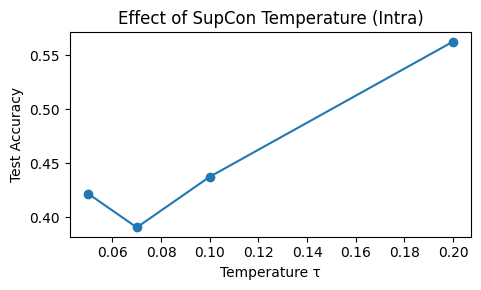

In [14]:
# NOTE: runs 4 full training loops — takes a few minutes.
temperatures = [0.05, 0.07, 0.1, 0.2]
temp_results = {}

for tau in temperatures:
    print(f'\n--- τ = {tau} ---')
    enc_t   = EEGNet(n_channels=N_CHANNELS, n_times=WINDOW_SIZE, embed_dim=EMBED_DIM).to(device)
    proj_t  = ProjectionHead(EMBED_DIM, PROJ_DIM).to(device)
    model_t = ContrastiveModel(enc_t, proj_t).to(device)
    opt_t   = torch.optim.Adam(model_t.parameters(), lr=1e-3, weight_decay=1e-4)

    pretrain_contrastive(model_t, intra_train_loader, opt_t,
                         SupConLoss(temperature=tau), epochs=PRETRAIN_EPOCHS)

    clf_t     = nn.Linear(EMBED_DIM, 4).to(device)
    clf_opt_t = torch.optim.Adam(clf_t.parameters(), lr=1e-3, weight_decay=1e-4)
    train_classifier(enc_t, clf_t, intra_train_loader, clf_opt_t, ce_loss, epochs=CLF_EPOCHS)

    acc_t, _, _ = evaluate(enc_t, clf_t, intra_test_loader)
    temp_results[tau] = acc_t
    print(f'  Test accuracy: {acc_t:.4f}')

plt.figure(figsize=(5, 3))
plt.plot(list(temp_results.keys()), list(temp_results.values()), marker='o')
plt.xlabel('Temperature τ'); plt.ylabel('Test Accuracy')
plt.title('Effect of SupCon Temperature (Intra)')
plt.tight_layout(); plt.show()

=== Full Fine-tuning (Cross, unfrozen encoder) ===
  [FineTune] Epoch  10/50 | Loss: 1.3617 | Acc: 0.2793
  [FineTune] Epoch  20/50 | Loss: 1.3282 | Acc: 0.3203
  [FineTune] Epoch  30/50 | Loss: 1.3061 | Acc: 0.3379
  [FineTune] Epoch  40/50 | Loss: 1.2783 | Acc: 0.4082
  [FineTune] Epoch  50/50 | Loss: 1.2413 | Acc: 0.4570

Cross test (frozen encoder):   0.2474
Cross test (unfrozen encoder): 0.2760

              precision    recall  f1-score   support

        Rest       0.30      0.32      0.31        96
       Motor       0.26      0.40      0.32        96
      Memory       0.27      0.14      0.18        96
  Story/Math       0.28      0.25      0.26        96

    accuracy                           0.28       384
   macro avg       0.28      0.28      0.27       384
weighted avg       0.28      0.28      0.27       384



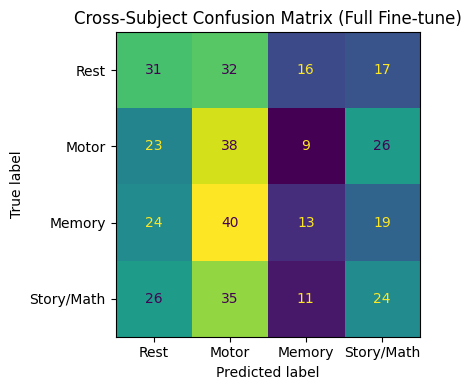

In [15]:
def finetune_full(encoder, clf, loader, optimizer, criterion, epochs=50):
    encoder.train(); clf.train()
    hist_loss, hist_acc = [], []
    for epoch in range(epochs):
        total_loss, correct, n = 0.0, 0, 0
        for xb, yb in loader:
            xb, yb   = xb.to(device), yb.to(device)
            logits   = clf(encoder(xb))
            loss     = criterion(logits, yb)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
            correct    += (logits.argmax(1) == yb).sum().item()
            n          += yb.size(0)
        hist_loss.append(total_loss / len(loader))
        hist_acc.append(correct / n)
        if (epoch + 1) % 10 == 0:
            print(f'  [FineTune] Epoch {epoch+1:3d}/{epochs} | Loss: {hist_loss[-1]:.4f} | Acc: {hist_acc[-1]:.4f}')
    return hist_loss, hist_acc


cross_encoder_ft  = copy.deepcopy(cross_encoder)
cross_clf_ft      = nn.Linear(EMBED_DIM, 4).to(device)
ft_opt = torch.optim.Adam(
    list(cross_encoder_ft.parameters()) + list(cross_clf_ft.parameters()),
    lr=1e-4, weight_decay=1e-4
)

print('=== Full Fine-tuning (Cross, unfrozen encoder) ===')
finetune_full(cross_encoder_ft, cross_clf_ft, cross_train_loader, ft_opt, ce_loss, epochs=50)

ft_test_acc, ft_preds, ft_labels = evaluate(cross_encoder_ft, cross_clf_ft, cross_test_loader)

print(f'\nCross test (frozen encoder):   {cross_test_acc:.4f}')
print(f'Cross test (unfrozen encoder): {ft_test_acc:.4f}')
print()
print(classification_report(ft_labels, ft_preds, target_names=CLASS_NAMES))
plot_confusion(ft_labels, ft_preds, 'Cross-Subject Confusion Matrix (Full Fine-tune)')